In [1]:
import pandas as pd

dataframe = pd.read_csv("../data/raw/risk_factors_cervical_cancer.csv")

print(f"Dataset: {dataframe.shape[0]} linhas e {dataframe.shape[1]} colunas")
dataframe.head()


Dataset: 858 linhas e 36 colunas


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs: Time since first diagnosis,STDs: Time since last diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology,Biopsy
0,18,4.0,15.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
1,15,1.0,14.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
2,34,1.0,?,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,?,?,0,0,0,0,0,0,0,0
3,52,5.0,16.0,4.0,1.0,37.0,37.0,1.0,3.0,0.0,...,?,?,1,0,1,0,0,0,0,0
4,46,3.0,21.0,4.0,0.0,0.0,0.0,1.0,15.0,0.0,...,?,?,0,0,0,0,0,0,0,0


In [2]:
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   Age                                 858 non-null    int64
 1   Number of sexual partners           858 non-null    str  
 2   First sexual intercourse            858 non-null    str  
 3   Num of pregnancies                  858 non-null    str  
 4   Smokes                              858 non-null    str  
 5   Smokes (years)                      858 non-null    str  
 6   Smokes (packs/year)                 858 non-null    str  
 7   Hormonal Contraceptives             858 non-null    str  
 8   Hormonal Contraceptives (years)     858 non-null    str  
 9   IUD                                 858 non-null    str  
 10  IUD (years)                         858 non-null    str  
 11  STDs                                858 non-null    str  
 12  STDs (number)      

In [3]:
import numpy as np

dataframe.replace('?', np.nan, inplace=True)
dataframe = dataframe.apply(pd.to_numeric)
dataframe.info()

<class 'pandas.DataFrame'>
RangeIndex: 858 entries, 0 to 857
Data columns (total 36 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Age                                 858 non-null    int64  
 1   Number of sexual partners           832 non-null    float64
 2   First sexual intercourse            851 non-null    float64
 3   Num of pregnancies                  802 non-null    float64
 4   Smokes                              845 non-null    float64
 5   Smokes (years)                      845 non-null    float64
 6   Smokes (packs/year)                 845 non-null    float64
 7   Hormonal Contraceptives             750 non-null    float64
 8   Hormonal Contraceptives (years)     750 non-null    float64
 9   IUD                                 741 non-null    float64
 10  IUD (years)                         741 non-null    float64
 11  STDs                                753 non-null    floa

In [4]:
null_percent = (dataframe.isnull().sum() / len(dataframe)) * 100

null_collumns = null_percent[null_percent > 0].sort_values(ascending=False)
print("Percentual de dados faltantes por coluna:")
print(null_collumns)

Percentual de dados faltantes por coluna:
STDs: Time since first diagnosis      91.724942
STDs: Time since last diagnosis       91.724942
IUD (years)                           13.636364
IUD                                   13.636364
Hormonal Contraceptives               12.587413
Hormonal Contraceptives (years)       12.587413
STDs (number)                         12.237762
STDs                                  12.237762
STDs:vulvo-perineal condylomatosis    12.237762
STDs:vaginal condylomatosis           12.237762
STDs:pelvic inflammatory disease      12.237762
STDs:syphilis                         12.237762
STDs:genital herpes                   12.237762
STDs:molluscum contagiosum            12.237762
STDs:HIV                              12.237762
STDs:AIDS                             12.237762
STDs:condylomatosis                   12.237762
STDs:cervical condylomatosis          12.237762
STDs:HPV                              12.237762
STDs:Hepatitis B                      12.23776

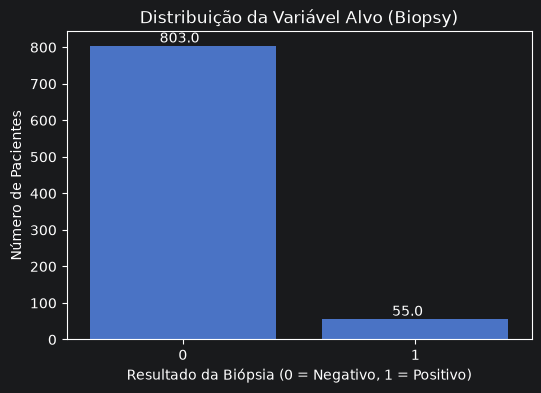

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
ax = sns.countplot(data=dataframe, x='Biopsy')
plt.title("Distribuição da Variável Alvo (Biopsy)")
plt.ylabel("Número de Pacientes")
plt.xlabel("Resultado da Biópsia (0 = Negativo, 1 = Positivo)")

for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + 0.3, p.get_height() + 10))

plt.show()

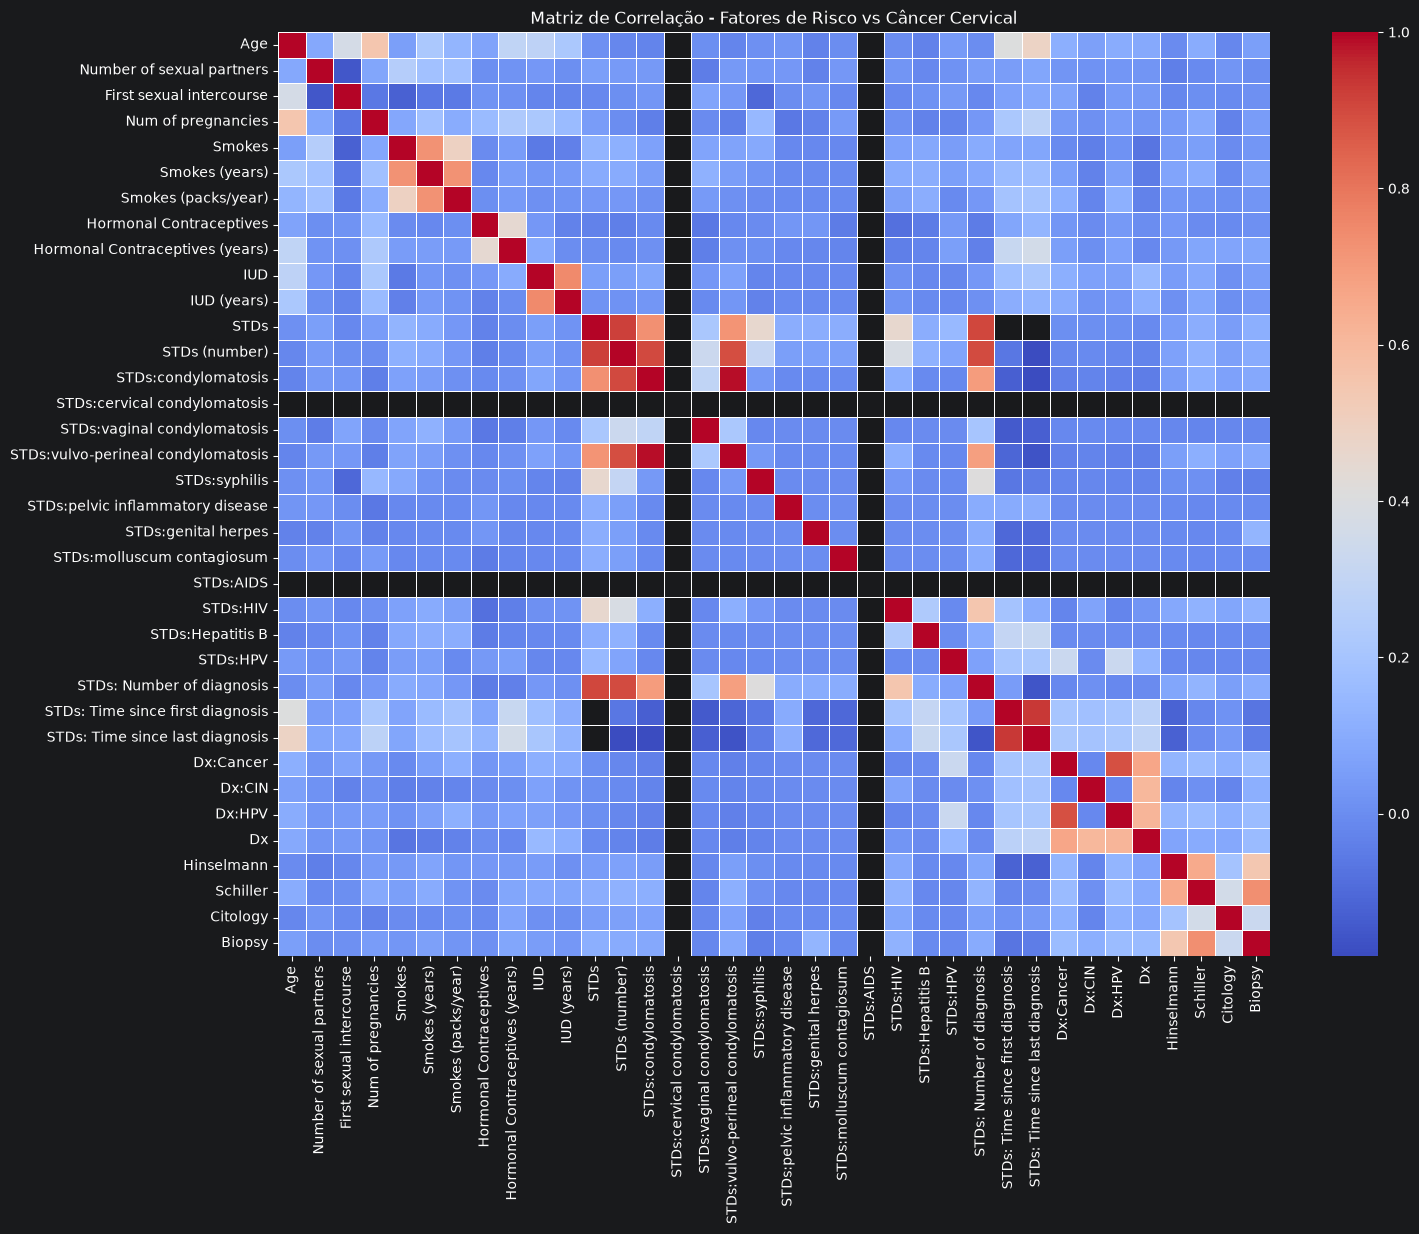

In [6]:
plt.figure(figsize=(16, 12))
matriz_correlacao = dataframe.corr()

sns.heatmap(matriz_correlacao, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Matriz de Correlação - Fatores de Risco vs Câncer Cervical")
plt.show()

In [7]:
y = dataframe['Biopsy']

X = dataframe.drop(columns=[
    'Biopsy',
    'STDs: Time since first diagnosis',
    'STDs: Time since last diagnosis'
])

print(f"Dimensão de X (Features): {X.shape}")
print(f"Dimensão de y (Alvo): {y.shape}")

Dimensão de X (Features): (858, 33)
Dimensão de y (Alvo): (858,)


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamanho do Treino: {X_train.shape[0]} amostras")
print(f"Tamanho do Teste: {X_test.shape[0]} amostras")

Tamanho do Treino: 686 amostras
Tamanho do Teste: 172 amostras


In [9]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

preprocessor = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

X_train_df = pd.DataFrame(X_train_processed, columns=X_train.columns)

print("Verificação do Pipeline: Quantidade de nulos após o processamento:")
print(X_train_df.isnull().sum().sum()) # Deve retornar 0
X_train_df.head()

Verificação do Pipeline: Quantidade de nulos após o processamento:
0


,Age,Number of sexual partners,First sexual intercourse,Num of pregnancies,Smokes,Smokes (years),Smokes (packs/year),Hormonal Contraceptives,Hormonal Contraceptives (years),IUD,...,STDs:Hepatitis B,STDs:HPV,STDs: Number of diagnosis,Dx:Cancer,Dx:CIN,Dx:HPV,Dx,Hinselmann,Schiller,Citology
0,0.472410,0.286643,-0.710920,1.894636,-0.41792,-0.298679,-0.201485,0.677919,-0.431636,-0.323527,...,-0.038208,-0.054074,-0.289184,-0.159408,-0.108625,-0.159408,-0.182023,-0.21385,-0.31241,-0.231869
1,-0.915484,-0.303858,-0.013222,-0.200561,-0.41792,-0.298679,-0.201485,0.677919,-0.431636,-0.323527,...,-0.038208,-0.054074,-0.289184,-0.159408,-0.108625,-0.159408,-0.182023,-0.21385,-0.31241,-0.231869
2,-0.105879,-0.303858,-0.710920,-0.200561,-0.41792,-0.298679,-0.201485,0.677919,-0.281778,3.090930,...,-0.038208,-0.054074,-0.289184,-0.159408,-0.108625,-0.159408,-0.182023,-0.21385,-0.31241,-0.231869
3,1.975961,0.286643,-0.710920,-0.200561,2.39280,0.000348,0.959957,-1.475102,-0.581494,-0.323527,...,-0.038208,-0.054074,-0.289184,-0.159408,-0.108625,-0.159408,-0.182023,-0.21385,-0.31241,-0.231869
4,-0.452853,-0.303858,0.335627,0.497838,-0.41792,-0.298679,-0.201485,-1.475102,-0.581494,-0.323527,...,-0.038208,-0.054074,-0.289184,-0.159408,-0.108625,-0.159408,-0.182023,-0.21385,-0.31241,-0.231869


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

modelo_lr = LogisticRegression(class_weight='balanced', random_state=42)
modelo_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42, n_jobs=-1)

print("Treinando Regressão Logística...")
modelo_lr.fit(X_train_processed, y_train)

print("Treinando Random Forest...")
modelo_rf.fit(X_train_processed, y_train)

previsoes_lr = modelo_lr.predict(X_test_processed)
previsoes_rf = modelo_rf.predict(X_test_processed)

print("Treinamento e predições concluídos com sucesso!")

Treinando Regressão Logística...
Treinando Random Forest...
Treinamento e predições concluídos com sucesso!


In [11]:
from sklearn.metrics import classification_report

print("=== AVALIAÇÃO: REGRESSÃO LOGÍSTICA ===")
print(classification_report(y_test, previsoes_lr))

print("\n=== AVALIAÇÃO: RANDOM FOREST ===")
print(classification_report(y_test, previsoes_rf))

=== AVALIAÇÃO: REGRESSÃO LOGÍSTICA ===
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       161
           1       0.64      0.82      0.72        11

    accuracy                           0.96       172
   macro avg       0.82      0.89      0.85       172
weighted avg       0.97      0.96      0.96       172


=== AVALIAÇÃO: RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       161
           1       0.73      0.73      0.73        11

    accuracy                           0.97       172
   macro avg       0.85      0.85      0.85       172
weighted avg       0.97      0.97      0.97       172



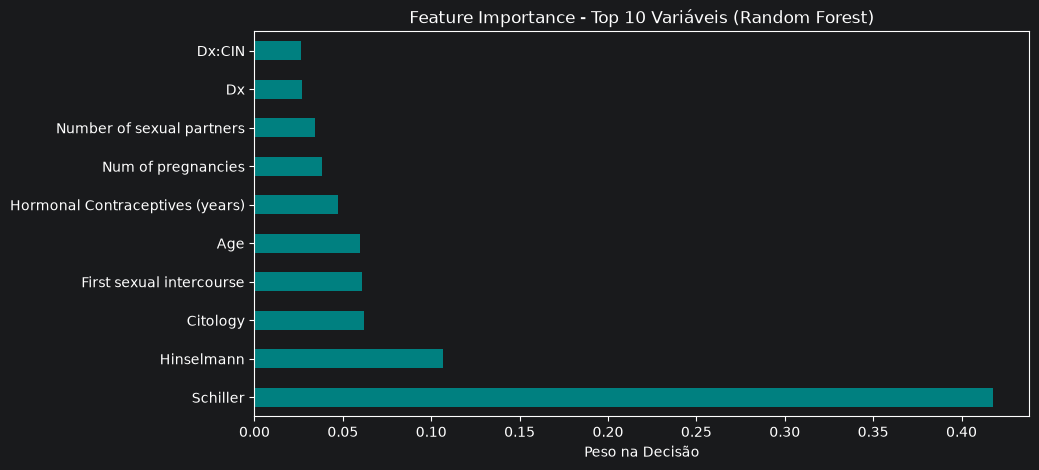

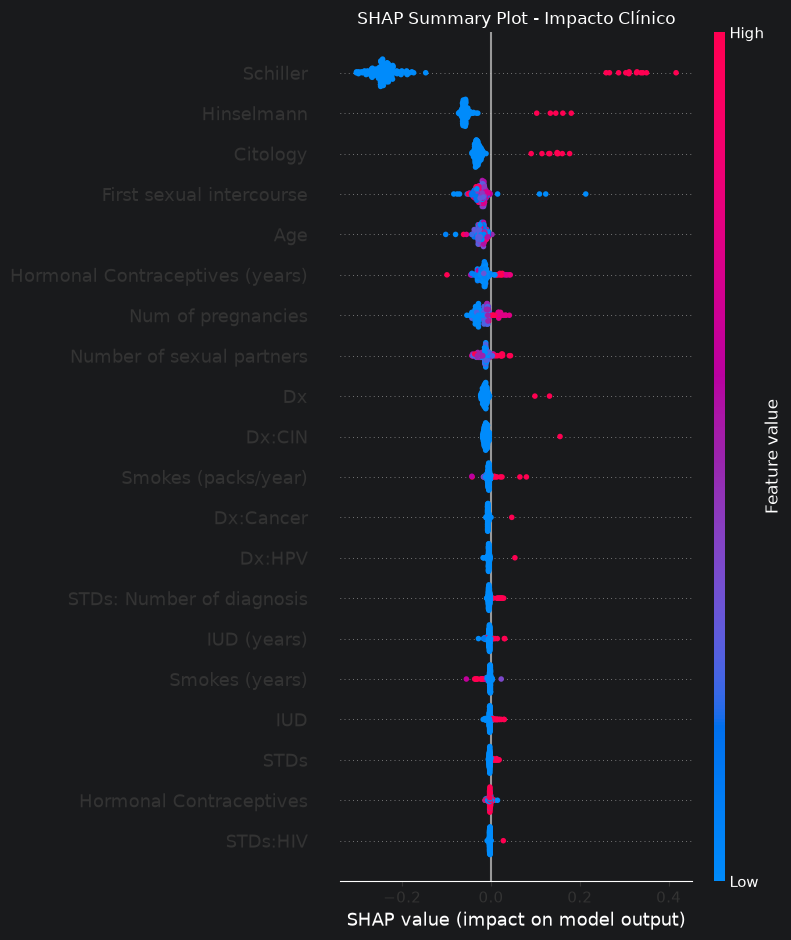

In [13]:
import shap
import matplotlib.pyplot as plt
import pandas as pd

# 1. Feature Importance Nativa
importances = pd.Series(modelo_rf.feature_importances_, index=X.columns)
importances.nlargest(10).plot(kind='barh', color='teal', figsize=(10, 5))
plt.title("Feature Importance - Top 10 Variáveis (Random Forest)")
plt.xlabel("Peso na Decisão")
plt.show()

explainer = shap.TreeExplainer(modelo_rf)
shap_values = explainer.shap_values(X_test_processed)

if isinstance(shap_values, list):
    shap_values_classe_1 = shap_values[1]
else:
    shap_values_classe_1 = shap_values[:, :, 1]

plt.title("SHAP Summary Plot - Impacto Clínico")
shap.summary_plot(shap_values_classe_1, X_test_processed, feature_names=X.columns)